In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
def lineStartsWith(line, patterns):
    if isinstance(patterns, str):
        pattern = patterns
        lenPat = len(pattern)
        if len(line) < lenPat:
            return False
        if line[0:lenPat] == pattern:
            return True
        return False
    else:
        for pattern in patterns:
            lenPat = len(pattern)
            if len(line) < lenPat:
                continue
            if line[0:lenPat] == pattern:
                return True
        return False

In [3]:
def normalizedPerf(timeVecs, n, kVec):
    # timeVecs is an array of arrays
    dim1,dim2 = timeVecs.shape
    retVec = np.zeros((dim1,dim2))
    numerVec = n*kVec**2
    for i in range(dim1):
        # for each vec in timeVecs
        for j in range(dim2):
            retVec[i][j] = numerVec[j] / (10**9 * timeVecs[i][j])
    return retVec

In [4]:
def createFigure(xVec, yVecs, labelVec, title, xLabel, yLabel, filename=None, xTicks=None, yTicks=None, yScale=None, nDash=0):
    fig,ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    numY = yVecs.shape[0]
    numL = labelVec.shape[0]

    if numY != numL:
        return

    if xTicks != None:
        ax.set_xticks(xTicks)

    if yTicks != None:
        ax.set_yticks(yTicks)
    else:
        ax.set_ylim(bottom=0, top=np.max(yVecs)*1.1)

    if yScale != None:
        ax.set_yscale(yScale)

    # Plot the first nDash elements as dashed lines
    for i in range(nDash):
        ax.plot(xVec, yVecs[i], '--', label=labelVec[i])
    # Plot the rest normally
    for i in range(nDash, numY):
        ax.plot(xVec, yVecs[i], label=labelVec[i])

    ax.legend()
    if filename != None:
        fig.savefig(filename)

In [5]:
def parseLarftFile(filename):
    # Row 1 is for qr
    # Row 2 is for lq
    # Column 1 is for Optimized (AOCL)
    # Column 2 is for Level 2 BLAS Implementation
    # Column 3 is for Recursive bailing to LVL2 termination
    # Column 4 is for UT computing inverse
    # Column 5 is for UT not computing inverse
    larft_times = np.zeros((2,5))
    larft_perf = np.zeros((2,5))

    qr_opt_time = np.zeros(0)
    qr_ref_2_time = np.zeros(0)
    qr_rec_lvl2_time = np.zeros(0)
    qr_ut_inv_time = np.zeros(0)
    qr_ut_solve_time = np.zeros(0)

    qr_opt_perf = np.zeros(0)
    qr_ref_2_perf = np.zeros(0)
    qr_rec_lvl2_perf = np.zeros(0)
    qr_ut_inv_perf = np.zeros(0)
    qr_ut_solve_perf = np.zeros(0)

    lq_opt_time = np.zeros(0)
    lq_ref_2_time = np.zeros(0)
    lq_rec_lvl2_time = np.zeros(0)
    lq_ut_inv_time = np.zeros(0)
    lq_ut_solve_time = np.zeros(0)

    lq_opt_perf = np.zeros(0)
    lq_ref_2_perf = np.zeros(0)
    lq_rec_lvl2_perf = np.zeros(0)
    lq_ut_inv_perf = np.zeros(0)
    lq_ut_solve_perf = np.zeros(0)

    nVec = np.zeros(0).astype('int')
    kVec = np.zeros(0).astype('int')
    
    firstRun = True
    numRepeat = 5.0
    with open(filename,'r') as file:
        lines = file.readlines()
        for line in lines:
            if lineStartsWith(line, "m="):
                line2 = line.split(":")
                n = int(line2[0][2:])
                k = int(line2[1][2:])

                nVec = np.append(nVec, n)
                kVec = np.append(kVec, k)
                if firstRun:
                    firstRun = False
                else:
                    # average our current times and performance metric
                    larft_times = larft_times / numRepeat
                    larft_perf = larft_perf / numRepeat

                    qr_opt_time = np.append(qr_opt_time,larft_times[0][0])
                    qr_ref_2_time = np.append(qr_ref_2_time, larft_times[0][1])
                    qr_rec_lvl2_time = np.append(qr_rec_lvl2_time, larft_times[0][2])
                    qr_ut_inv_time = np.append(qr_ut_inv_time, larft_times[0][3])
                    qr_ut_solve_time = np.append(qr_ut_solve_time, larft_times[0][4])

                    qr_opt_perf = np.append(qr_opt_perf,larft_perf[0][0])
                    qr_ref_2_perf = np.append(qr_ref_2_perf, larft_perf[0][1])
                    qr_rec_lvl2_perf = np.append(qr_rec_lvl2_perf, larft_perf[0][2])
                    qr_ut_inv_perf = np.append(qr_ut_inv_perf, larft_perf[0][3])
                    qr_ut_solve_perf = np.append(qr_ut_solve_perf, larft_perf[0][4])

                    lq_opt_time = np.append(lq_opt_time,larft_times[1][0])
                    lq_ref_2_time = np.append(lq_ref_2_time, larft_times[1][1])
                    lq_rec_lvl2_time = np.append(lq_rec_lvl2_time, larft_times[1][2])
                    lq_ut_inv_time = np.append(lq_ut_inv_time, larft_times[1][3])
                    lq_ut_solve_time = np.append(lq_ut_solve_time, larft_times[1][4])

                    lq_opt_perf = np.append(lq_opt_perf,larft_perf[1][0])
                    lq_ref_2_perf = np.append(lq_ref_2_perf, larft_perf[1][1])
                    lq_rec_lvl2_perf = np.append(lq_rec_lvl2_perf, larft_perf[1][2])
                    lq_ut_inv_perf = np.append(lq_ut_inv_perf, larft_perf[1][3])
                    lq_ut_solve_perf = np.append(lq_ut_solve_perf, larft_perf[1][4])

                    larft_times = np.zeros((2,5))
                    larft_perf = np.zeros((2,5))
            elif lineStartsWith(line.strip(), ["QR","LQ"]):
                line2 = line.split(":")
                valueString = re.sub(r'\s+', ' ', line2[1].strip())
                values = valueString.split(" ")

                opt_val = float(values[0])
                ref_2_val = float(values[1])
                rec_lvl2_val = float(values[2])
                ut_inv_val = float(values[3])
                ut_solve_val = float(values[4])

                if lineStartsWith(line.strip(), "QR PERF"):
                    larft_perf[0][0] += opt_val
                    larft_perf[0][1] += ref_2_val
                    larft_perf[0][2] += rec_lvl2_val
                    larft_perf[0][3] += ut_inv_val
                    larft_perf[0][4] += ut_solve_val
                elif lineStartsWith(line.strip(), "QR TIMES"):
                    larft_times[0][0] += opt_val
                    larft_times[0][1] += ref_2_val
                    larft_times[0][2] += rec_lvl2_val
                    larft_times[0][3] += ut_inv_val
                    larft_times[0][4] += ut_solve_val
                elif lineStartsWith(line.strip(), "LQ PERF"):
                    larft_perf[1][0] += opt_val
                    larft_perf[1][1] += ref_2_val
                    larft_perf[1][2] += rec_lvl2_val
                    larft_perf[1][3] += ut_inv_val
                    larft_perf[1][4] += ut_solve_val
                else:
                    larft_times[1][0] += opt_val
                    larft_times[1][1] += ref_2_val
                    larft_times[1][2] += rec_lvl2_val
                    larft_times[1][3] += ut_inv_val
                    larft_times[1][4] += ut_solve_val
    larft_times = larft_times / numRepeat
    larft_perf = larft_perf / numRepeat

    qr_opt_time = np.append(qr_opt_time,larft_times[0][0])
    qr_ref_2_time = np.append(qr_ref_2_time, larft_times[0][1])
    qr_rec_lvl2_time = np.append(qr_rec_lvl2_time, larft_times[0][2])
    qr_ut_inv_time = np.append(qr_ut_inv_time, larft_times[0][3])
    qr_ut_solve_time = np.append(qr_ut_solve_time, larft_times[0][4])
    
    qr_opt_perf = np.append(qr_opt_perf,larft_perf[0][0])
    qr_ref_2_perf = np.append(qr_ref_2_perf, larft_perf[0][1])
    qr_rec_lvl2_perf = np.append(qr_rec_lvl2_perf, larft_perf[0][2])
    qr_ut_inv_perf = np.append(qr_ut_inv_perf, larft_perf[0][3])
    qr_ut_solve_perf = np.append(qr_ut_solve_perf, larft_perf[0][4])
    
    lq_opt_time = np.append(lq_opt_time,larft_times[1][0])
    lq_ref_2_time = np.append(lq_ref_2_time, larft_times[1][1])
    lq_rec_lvl2_time = np.append(lq_rec_lvl2_time, larft_times[1][2])
    lq_ut_inv_time = np.append(lq_ut_inv_time, larft_times[1][3])
    lq_ut_solve_time = np.append(lq_ut_solve_time, larft_times[1][4])
    
    lq_opt_perf = np.append(lq_opt_perf,larft_perf[1][0])
    lq_ref_2_perf = np.append(lq_ref_2_perf, larft_perf[1][1])
    lq_rec_lvl2_perf = np.append(lq_rec_lvl2_perf, larft_perf[1][2])
    lq_ut_inv_perf = np.append(lq_ut_inv_perf, larft_perf[1][3])
    lq_ut_solve_perf = np.append(lq_ut_solve_perf, larft_perf[1][4])

    return (nVec, kVec, \
            qr_opt_time, qr_ref_2_time, qr_rec_lvl2_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_2_perf, qr_rec_lvl2_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_2_time, lq_rec_lvl2_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_2_perf, lq_rec_lvl2_perf, lq_ut_inv_perf, lq_ut_solve_perf)

In [6]:
def parseOrgFile(filename):
    # Row 1 is for qr
    # Row 2 is for lq
    # Column 1 is for Optimized (AOCL)
    # Column 2 is for Reference version
    # Column 3 is for Level 2 BLAS Implementation
    # Column 4 is for Recursive bailing to LVL2 termination
    # Column 5 is for UT computing inverse
    # Column 6 is for UT not computing inverse
    orgqr_times = np.zeros((2,6))
    orgqr_perf = np.zeros((2,6))

    qr_opt_time = np.zeros(0)
    qr_ref_time = np.zeros(0)
    qr_lvl2_time = np.zeros(0)
    qr_rec_time = np.zeros(0)
    qr_ut_inv_time = np.zeros(0)
    qr_ut_solve_time = np.zeros(0)

    qr_opt_perf = np.zeros(0)
    qr_ref_perf = np.zeros(0)
    qr_lvl2_perf = np.zeros(0)
    qr_rec_perf = np.zeros(0)
    qr_ut_inv_perf = np.zeros(0)
    qr_ut_solve_perf = np.zeros(0)

    lq_opt_time = np.zeros(0)
    lq_ref_time = np.zeros(0)
    lq_lvl2_time = np.zeros(0)
    lq_rec_time = np.zeros(0)
    lq_ut_inv_time = np.zeros(0)
    lq_ut_solve_time = np.zeros(0)

    lq_opt_perf = np.zeros(0)
    lq_ref_perf = np.zeros(0)
    lq_lvl2_perf = np.zeros(0)
    lq_rec_perf = np.zeros(0)
    lq_ut_inv_perf = np.zeros(0)
    lq_ut_solve_perf = np.zeros(0)

    mVec = np.zeros(0).astype('int')
    nVec = np.zeros(0).astype('int')
    kVec = np.zeros(0).astype('int')
    nbVec = np.zeros(0).astype('int')
    
    firstRun = True
    numRepeat = 5.0

    with open(filename,'r') as file:
        lines = file.readlines()
        for line in lines:
            if lineStartsWith(line, "m="):
                line2 = line.split(":")
                m = int(line2[0][2:])
                n = int(line2[1][2:])
                k = int(line2[2][2:])
                nb = int(line2[3][3:])

                mVec = np.append(mVec, m)
                nVec = np.append(nVec, n)
                kVec = np.append(kVec, k)
                nbVec = np.append(nbVec, nb)
                if firstRun:
                    firstRun = False
                else:
                    # average our current times and performance metric
                    orgqr_times = orgqr_times / numRepeat
                    orgqr_perf = orgqr_perf / numRepeat

                    qr_opt_time = np.append(qr_opt_time, orgqr_times[0][0])
                    qr_ref_time = np.append(qr_ref_time, orgqr_times[0][1])
                    qr_lvl2_time = np.append(qr_lvl2_time, orgqr_times[0][2])
                    qr_rec_time = np.append(qr_rec_time, orgqr_times[0][3])
                    qr_ut_inv_time = np.append(qr_ut_inv_time, orgqr_times[0][4])
                    qr_ut_solve_time = np.append(qr_ut_solve_time, orgqr_times[0][5])

                    qr_opt_perf = np.append(qr_opt_perf, orgqr_perf[0][0])
                    qr_ref_perf = np.append(qr_ref_perf, orgqr_perf[0][1])
                    qr_lvl2_perf = np.append(qr_lvl2_perf, orgqr_perf[0][2])
                    qr_rec_perf = np.append(qr_rec_perf, orgqr_perf[0][3])
                    qr_ut_inv_perf = np.append(qr_ut_inv_perf, orgqr_perf[0][4])
                    qr_ut_solve_perf = np.append(qr_ut_solve_perf, orgqr_perf[0][5])

                    lq_opt_time = np.append(lq_opt_time, orgqr_times[1][0])
                    lq_ref_time = np.append(lq_ref_time, orgqr_times[1][1])
                    lq_lvl2_time = np.append(lq_lvl2_time, orgqr_times[1][2])
                    lq_rec_time = np.append(lq_rec_time, orgqr_times[1][3])
                    lq_ut_inv_time = np.append(lq_ut_inv_time, orgqr_times[1][4])
                    lq_ut_solve_time = np.append(lq_ut_solve_time, orgqr_times[1][5])

                    lq_opt_perf = np.append(lq_opt_perf, orgqr_perf[1][0])
                    lq_ref_perf = np.append(lq_ref_perf, orgqr_perf[1][1])
                    lq_lvl2_perf = np.append(lq_lvl2_perf, orgqr_perf[1][2])
                    lq_rec_perf = np.append(lq_rec_perf, orgqr_perf[1][3])
                    lq_ut_inv_perf = np.append(lq_ut_inv_perf, orgqr_perf[1][4])
                    lq_ut_solve_perf = np.append(lq_ut_solve_perf, orgqr_perf[1][5])

                    orgqr_times = np.zeros((2,6))
                    orgqr_perf = np.zeros((2,6))
            elif lineStartsWith(line.strip(), ["QR","LQ"]):
                line2 = line.split(":")
                valueString = re.sub(r'\s+', ' ', line2[1].strip())
                values = valueString.split(" ")

                opt_val = float(values[0])
                ref_val = float(values[1])
                lvl2_val= float(values[2])
                rec_val = float(values[3])
                ut_inv_val = float(values[4])
                ut_solve_val = float(values[5])

                if lineStartsWith(line.strip(), "QR_PERF"):
                    orgqr_perf[0][0] += opt_val
                    orgqr_perf[0][1] += ref_val
                    orgqr_perf[0][2] += lvl2_val
                    orgqr_perf[0][3] += rec_val
                    orgqr_perf[0][4] += ut_inv_val
                    orgqr_perf[0][5] += ut_solve_val
                elif lineStartsWith(line.strip(), "QR_TIMES"):
                    orgqr_times[0][0] += opt_val
                    orgqr_times[0][1] += ref_val
                    orgqr_times[0][2] += lvl2_val
                    orgqr_times[0][3] += rec_val
                    orgqr_times[0][4] += ut_inv_val
                    orgqr_times[0][5] += ut_solve_val
                elif lineStartsWith(line.strip(), "LQ_PERF"):
                    orgqr_perf[1][0] += opt_val
                    orgqr_perf[1][1] += ref_val
                    orgqr_perf[1][2] += lvl2_val
                    orgqr_perf[1][3] += rec_val
                    orgqr_perf[1][4] += ut_inv_val
                    orgqr_perf[1][5] += ut_solve_val
                else:
                    orgqr_times[1][0] += opt_val
                    orgqr_times[1][1] += ref_val
                    orgqr_times[1][2] += lvl2_val
                    orgqr_times[1][3] += rec_val
                    orgqr_times[1][4] += ut_inv_val
                    orgqr_times[1][5] += ut_solve_val
    orgqr_times = orgqr_times / numRepeat
    orgqr_perf = orgqr_perf / numRepeat

    qr_opt_time = np.append(qr_opt_time, orgqr_times[0][0])
    qr_ref_time = np.append(qr_ref_time, orgqr_times[0][1])
    qr_lvl2_time = np.append(qr_lvl2_time, orgqr_times[0][2])
    qr_rec_time = np.append(qr_rec_time, orgqr_times[0][3])
    qr_ut_inv_time = np.append(qr_ut_inv_time, orgqr_times[0][4])
    qr_ut_solve_time = np.append(qr_ut_solve_time, orgqr_times[0][5])

    qr_opt_perf = np.append(qr_opt_perf, orgqr_perf[0][0])
    qr_ref_perf = np.append(qr_ref_perf, orgqr_perf[0][1])
    qr_lvl2_perf = np.append(qr_lvl2_perf, orgqr_perf[0][2])
    qr_rec_perf = np.append(qr_rec_perf, orgqr_perf[0][3])
    qr_ut_inv_perf = np.append(qr_ut_inv_perf, orgqr_perf[0][4])
    qr_ut_solve_perf = np.append(qr_ut_solve_perf, orgqr_perf[0][5])

    lq_opt_time = np.append(lq_opt_time, orgqr_times[1][0])
    lq_ref_time = np.append(lq_ref_time, orgqr_times[1][1])
    lq_lvl2_time = np.append(lq_lvl2_time, orgqr_times[1][2])
    lq_rec_time = np.append(lq_rec_time, orgqr_times[1][3])
    lq_ut_inv_time = np.append(lq_ut_inv_time, orgqr_times[1][4])
    lq_ut_solve_time = np.append(lq_ut_solve_time, orgqr_times[1][5])

    lq_opt_perf = np.append(lq_opt_perf, orgqr_perf[1][0])
    lq_ref_perf = np.append(lq_ref_perf, orgqr_perf[1][1])
    lq_lvl2_perf = np.append(lq_lvl2_perf, orgqr_perf[1][2])
    lq_rec_perf = np.append(lq_rec_perf, orgqr_perf[1][3])
    lq_ut_inv_perf = np.append(lq_ut_inv_perf, orgqr_perf[1][4])
    lq_ut_solve_perf = np.append(lq_ut_solve_perf, orgqr_perf[1][5])

    return (mVec, nVec, kVec, nbVec, \
            qr_opt_time, qr_ref_time, qr_lvl2_time, qr_rec_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_perf, qr_lvl2_perf, qr_rec_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_time, lq_lvl2_time, lq_rec_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_perf, lq_lvl2_perf, lq_rec_perf, lq_ut_inv_perf, lq_ut_solve_perf)

In [7]:
def parseLarfbFile(filename):
    # Row 1 holds our values
    # Column 1 is for Optimized (AOCL)
    # Column 2 is for Reference version
    # Column 3 is for the new version
    # Column 4 is for the new version with trsm(UT not computing inverse)
    larfb_times = np.zeros((2,4))

    opt_time = np.zeros(0)
    ref_time = np.zeros(0)
    new_time = np.zeros(0)
    new_solve_time = np.zeros(0)

    mVec = np.zeros(0).astype('int')
    nVec = np.zeros(0).astype('int')
    kVec = np.zeros(0).astype('int')
    
    firstRun = True
    numRepeat = 5.0

    with open(filename,'r') as file:
        lines = file.readlines()
        for line in lines:
            if lineStartsWith(line, "m="):
                line2 = line.split(":")
                m = int(line2[0][2:])
                n = int(line2[1][2:])
                k = int(line2[2][2:])

                mVec = np.append(mVec, m)
                nVec = np.append(nVec, n)
                kVec = np.append(kVec, k)
                if firstRun:
                    firstRun = False
                else:
                    # average our current times and performance metric
                    larfb_times = larfb_times / numRepeat

                    opt_time = np.append(opt_time, larfb_times[0][0])
                    ref_time = np.append(ref_time, larfb_times[0][1])
                    new_time = np.append(new_time, larfb_times[0][2])
                    new_solve_time = np.append(new_solve_time, larfb_times[0][3])

                    larfb_times = np.zeros((2,4))
            else:
                valueString = re.sub(r'\s+', ' ', line.strip())
                values = valueString.split(" ")

                opt_val = float(values[0])
                ref_val = float(values[1])
                new_val = float(values[2])
                new_solve_val = float(values[3])

                larfb_times[0][0] += opt_val
                larfb_times[0][1] += ref_val
                larfb_times[0][2] += new_val
                larfb_times[0][3] += new_solve_val
    larfb_times = larfb_times / numRepeat

    opt_time = np.append(opt_time, larfb_times[0][0])
    ref_time = np.append(ref_time, larfb_times[0][1])
    new_time = np.append(new_time, larfb_times[0][2])
    new_solve_time = np.append(new_solve_time, larfb_times[0][3])

    return (mVec, nVec, kVec, \
            opt_time, ref_time, new_time, new_solve_time)

In [8]:
(nVec, kVec, \
            qr_opt_time, qr_ref_2_time, qr_rec_lvl2_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_2_perf, qr_rec_lvl2_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_2_time, lq_rec_lvl2_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_2_perf, lq_rec_lvl2_perf, lq_ut_inv_perf, lq_ut_solve_perf) = parseLarftFile("small_larft_12_06_25.txt")

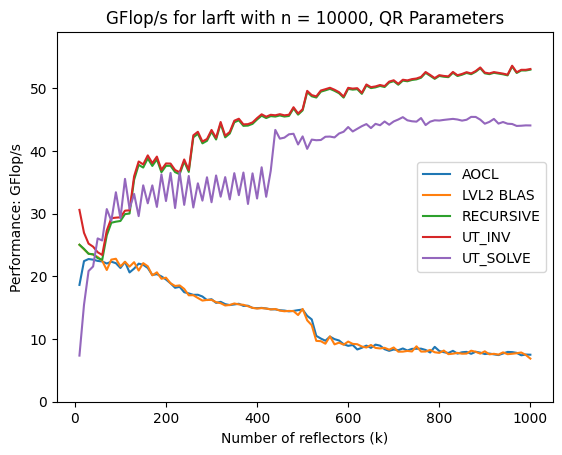

In [9]:
xVec = kVec
yVecs = np.array([qr_opt_perf, qr_ref_2_perf, qr_rec_lvl2_perf, qr_ut_inv_perf, qr_ut_solve_perf])

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for larft with n = 10000, QR Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="qr_larft_10000_k.png")

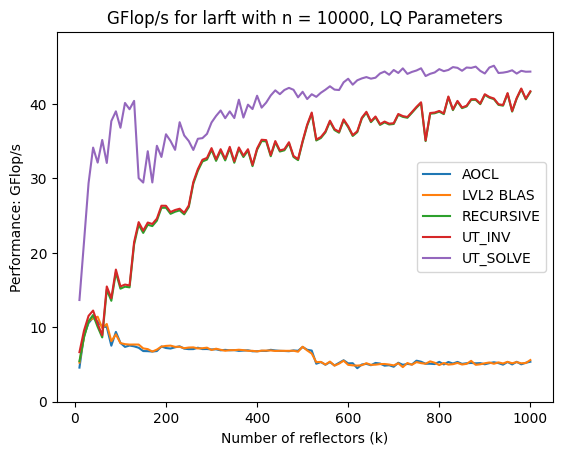

In [10]:
xVec = kVec
yVecs = np.array([lq_opt_perf, lq_ref_2_perf, lq_rec_lvl2_perf, lq_ut_inv_perf, lq_ut_solve_perf])

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for larft with n = 10000, LQ Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="lq_larft_10000_k.png")

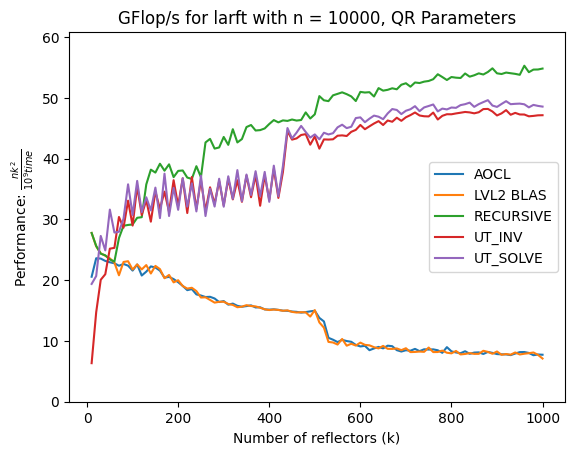

In [11]:
xVec = kVec
yVecTmp = np.array([qr_opt_time, qr_ref_2_time, qr_rec_lvl2_time, qr_ut_inv_time, qr_ut_solve_time])
yVecs = normalizedPerf(yVecTmp, nVec[0], xVec)

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = r'Performance: $\frac{nk^2}{10^9time}$'
title = "GFlop/s for larft with n = 10000, QR Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="qr_larft_norm_10000_k.png")

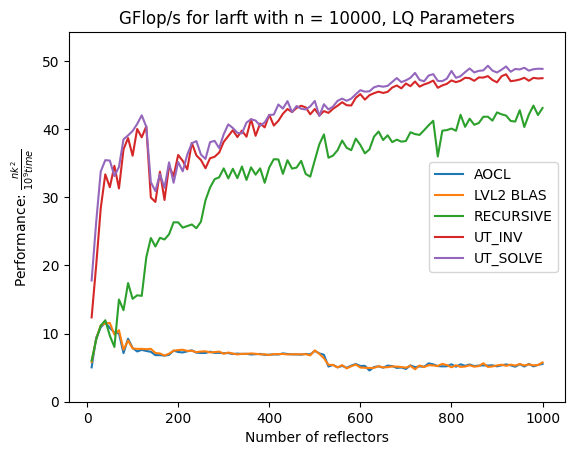

In [12]:
xVec = kVec
yVecTmp = np.array([lq_opt_time, lq_ref_2_time, lq_rec_lvl2_time, lq_ut_inv_time, lq_ut_solve_time])
yVecs = normalizedPerf(yVecTmp, nVec[0], xVec)

labelVecs = np.array(["AOCL", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors"
yLabel = r'Performance: $\frac{nk^2}{10^9time}$'
title = "GFlop/s for larft with n = 10000, LQ Parameters"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="lq_larft_norm_10000_k.png")

In [13]:
(mVec, nVec, kVec, nbVec, \
            qr_opt_time, qr_ref_time, qr_lvl2_time, qr_rec_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_perf, qr_lvl2_perf, qr_rec_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_time, lq_lvl2_time, lq_rec_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_perf, lq_lvl2_perf, lq_rec_perf, lq_ut_inv_perf, lq_ut_solve_perf) = parseOrgFile("rect_orgqr_12_06_25.txt")

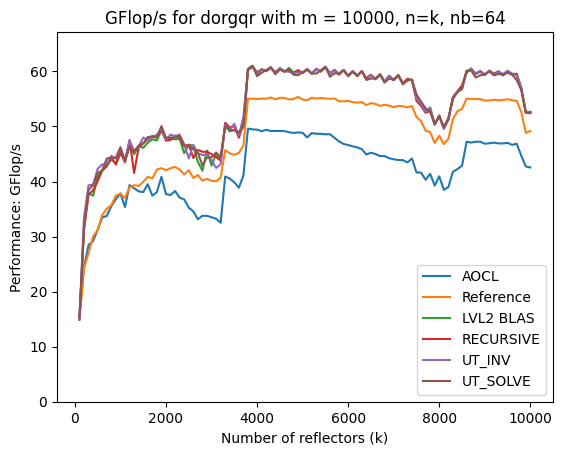

In [14]:
xVec = kVec
yVecs = np.array([qr_opt_perf, qr_ref_perf, qr_lvl2_perf, qr_rec_perf, qr_ut_inv_perf, qr_ut_solve_perf])
labelVecs = np.array(["AOCL", "Reference", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for dorgqr with m = 10000, n=k, nb=64"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="qr_org_10000_k.png")

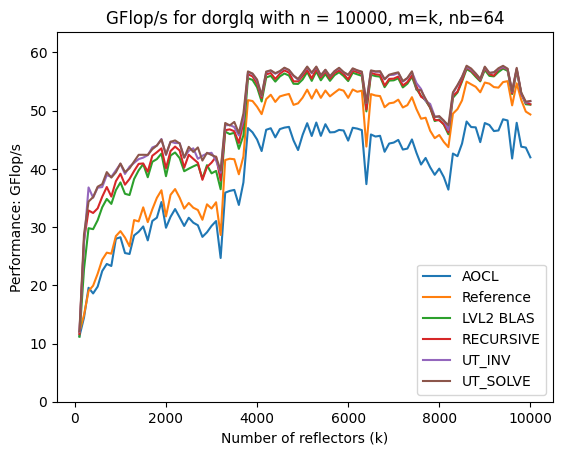

In [15]:
xVec = kVec
yVecs = np.array([lq_opt_perf, lq_ref_perf, lq_lvl2_perf, lq_rec_perf, lq_ut_inv_perf, lq_ut_solve_perf])
labelVecs = np.array(["AOCL", "Reference", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = "GFlop/s for dorglq with n = 10000, m=k, nb=64"
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="lq_org_10000_k.png")

In [16]:
(mVec, nVec, kVec, nbVec, \
            qr_opt_time, qr_ref_time, qr_lvl2_time, qr_rec_time, qr_ut_inv_time, qr_ut_solve_time, \
            qr_opt_perf, qr_ref_perf, qr_lvl2_perf, qr_rec_perf, qr_ut_inv_perf, qr_ut_solve_perf, \
            lq_opt_time, lq_ref_time, lq_lvl2_time, lq_rec_time, lq_ut_inv_time, lq_ut_solve_time, \
            lq_opt_perf, lq_ref_perf, lq_lvl2_perf, lq_rec_perf, lq_ut_inv_perf, lq_ut_solve_perf) = parseOrgFile("rect_orgqr_nb_12_06_25.txt")

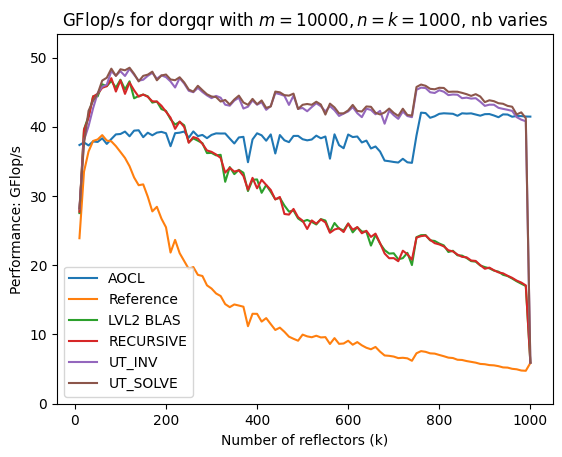

In [17]:
xVec = nbVec
yVecs = np.array([qr_opt_perf, qr_ref_perf, qr_lvl2_perf, qr_rec_perf, qr_ut_inv_perf, qr_ut_solve_perf])
labelVecs = np.array(["AOCL", "Reference", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = r'GFlop/s for dorgqr with $m=10000, n=k=1000$, nb varies'
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="qr_org_10000_nb.png")

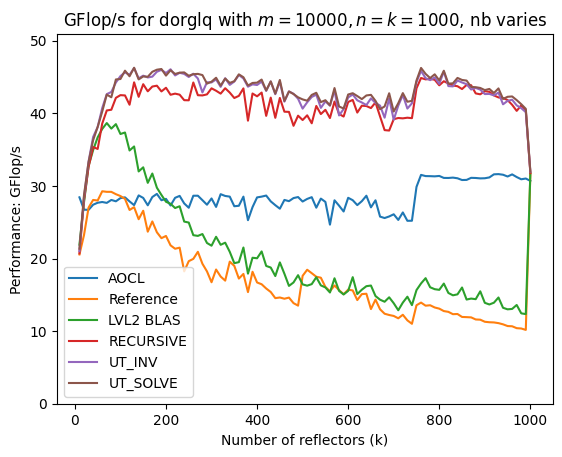

In [18]:
xVec = nbVec
yVecs = np.array([lq_opt_perf, lq_ref_perf, lq_lvl2_perf, lq_rec_perf, lq_ut_inv_perf, lq_ut_solve_perf])
labelVecs = np.array(["AOCL", "Reference", "LVL2 BLAS", "RECURSIVE", "UT_INV", "UT_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = r'GFlop/s for dorglq with $m=10000, n=k=1000$, nb varies'
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="lq_org_10000_nb.png")

In [19]:
(mVec, nVec, kVec, \
            opt_time, ref_time, new_time, new_solve_time) = parseLarfbFile("rect_larfb_12_06_25.txt")

In [20]:
def larfbPerf(m,n,k,time):
    tmp = 4.0*m*n*k - 2.0*n*k**2
    return tmp / (time*10**9)

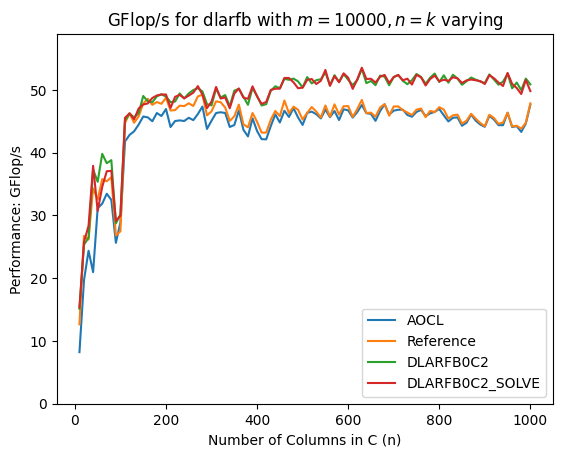

In [21]:
xVec = kVec
yVecs = np.array([opt_time, ref_time, new_time, new_solve_time])
for i in range(yVecs.shape[0]):
    yVecs[i][:] = larfbPerf(mVec,nVec,kVec,yVecs[i][:])
labelVecs = np.array(["AOCL", "Reference", "DLARFB0C2", "DLARFB0C2_SOLVE"])
xLabel = "Number of Columns in C (n)"
yLabel = "Performance: GFlop/s"
title = r'GFlop/s for dlarfb with $m=10000, n=k$ varying'
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="rect_larfb_10000.png")

In [22]:
(mVec, nVec, kVec, \
            opt_time, ref_time, new_time, new_solve_time) = parseLarfbFile("square_larfb_12_06_25.txt")

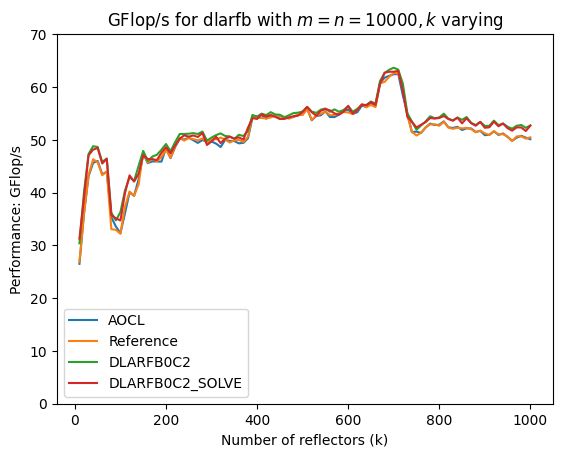

In [23]:
xVec = kVec
yVecs = np.array([opt_time, ref_time, new_time, new_solve_time])
for i in range(yVecs.shape[0]):
    yVecs[i][:] = larfbPerf(mVec,nVec,kVec,yVecs[i][:])
labelVecs = np.array(["AOCL", "Reference", "DLARFB0C2", "DLARFB0C2_SOLVE"])
xLabel = "Number of reflectors (k)"
yLabel = "Performance: GFlop/s"
title = r'GFlop/s for dlarfb with $m=n=10000, k$ varying'
createFigure(xVec, yVecs, labelVecs, title, xLabel, yLabel, filename="square_larfb_10000.png")